Codveda Technologies ; Level 2 Task 2: Time Series 

Import and load dataset


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose

In [2]:
Stock_prices = pd.read_csv(r"c:\Users\User\Documents\Stock Prices Data Set.csv")

In [3]:
Stock_prices.head()

,symbol,date,open,high,low,close,volume
0,AAL,2/01/2014,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2/01/2014,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2/01/2014,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2/01/2014,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2/01/2014,70.1100,70.2300,69.4800,69.8900,1148391


In [4]:
Stock_prices.columns = Stock_prices.columns.str.strip().str.lower()
Stock_prices.columns

Index(['symbol', 'date', 'open', 'high', 'low', 'close', 'volume'], dtype='object')

In [5]:
Stock_prices['date'] = pd.to_datetime(Stock_prices['date'],dayfirst=True,errors='coerce')

In [6]:
Stock_prices.set_index('date', inplace=True)
Stock_prices.head()

,symbol,open,high,low,close,volume
date,,,,,,
2014-01-02,AAL,25.0700,25.8200,25.0600,25.3600,8998943
2014-01-02,AAPL,79.3828,79.5756,78.8601,79.0185,58791957
2014-01-02,AAP,110.3600,111.8800,109.2900,109.7400,542711
2014-01-02,ABBV,52.1200,52.3300,51.5200,51.9800,4569061
2014-01-02,ABC,70.1100,70.2300,69.4800,69.8900,1148391


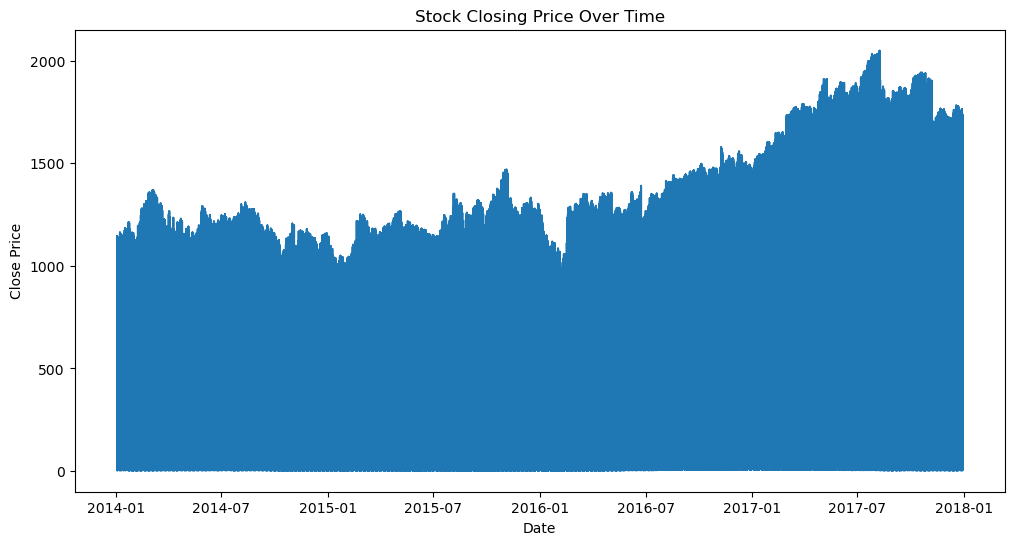

In [7]:
plt.figure(figsize=(12,6))
plt.plot(Stock_prices['close'])
plt.title("Stock Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")

plt.show()

In [8]:
Stock_prices['MA_30'] = Stock_prices['close'].rolling(window=30).mean()

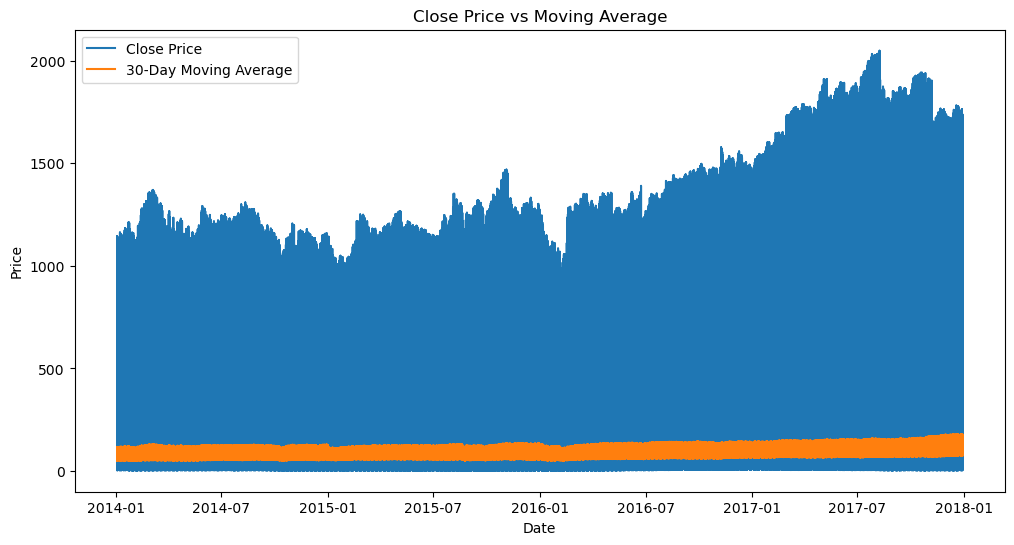

In [9]:
plt.figure(figsize=(12,6))

plt.plot(Stock_prices['close'], label='Close Price')
plt.plot(Stock_prices['MA_30'], label='30-Day Moving Average')

plt.title("Close Price vs Moving Average")
plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()
plt.show()

In [10]:
result = seasonal_decompose(Stock_prices['close'],model='additive',period=30)

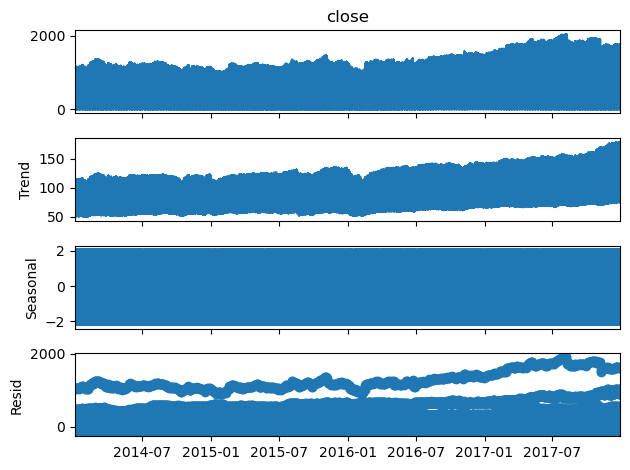

In [11]:
result.plot()
plt.show()

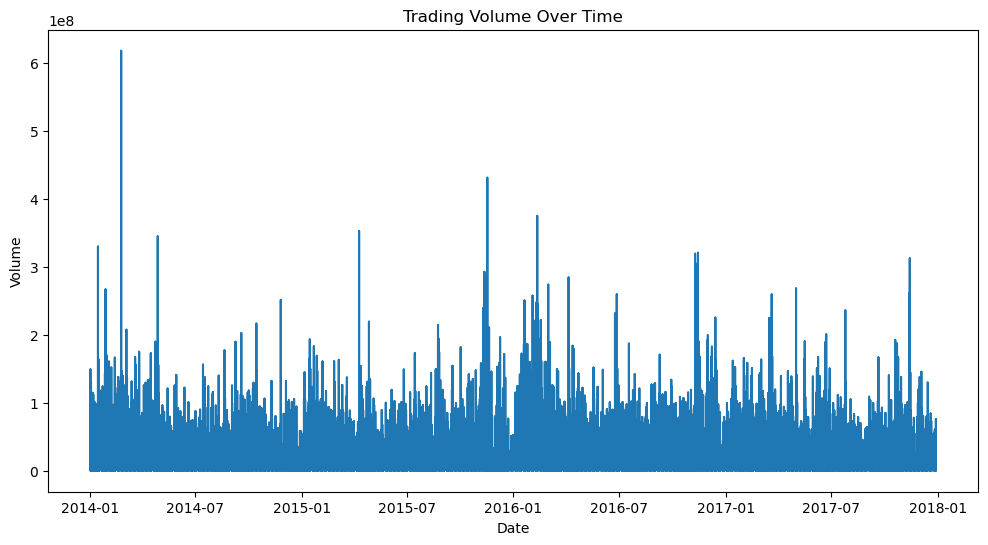

In [12]:
plt.figure(figsize=(12,6))

plt.plot(Stock_prices['volume'])

plt.title("Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")

plt.show()